# Coffee Sales

## P2: Product Popularity & Demand Forecasting
- Objective: Forecast future sales and identify product demand cycles.

    - Charts/Visuals:
        - Daily sales trend by product (stacked area chart).
        - Rolling 7-day average sales (line chart).
        - Product market share (stacked bar).
        - Seasonal decomposition (trend/seasonality).
        - Correlation heatmap between features (coffee type, time, sales).
        - Boxplot of spending per customer (outlier detection).
    - ML Models:
        - Feature engineering: lags, rolling averages, month/weekday encoding.
        - XGBoost Regressor – Forecast product-wise sales.
        - Decision Tree Regressor - Baseline ML model for lag features.
        - Evaluation: MAPE, MAE.

In [2]:
# ============================
# P2: Product Popularity & Demand Forecasting
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Set pastel theme
sns.set_theme(style="whitegrid", palette="pastel")

In [3]:
# ============================
# Load Dataset
# ============================
df = pd.read_csv("index.csv")

# Preview
print("Shape:", df.shape)
df.head()

Shape: (1133, 6)


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
# ============================
# Data Prep for Forecasting
# ============================
# Aggregate daily sales
daily_sales = df.groupby('date')['money'].sum().reset_index()

# Ensure continuous date index
daily_sales = daily_sales.set_index('date').asfreq('D', fill_value=0)

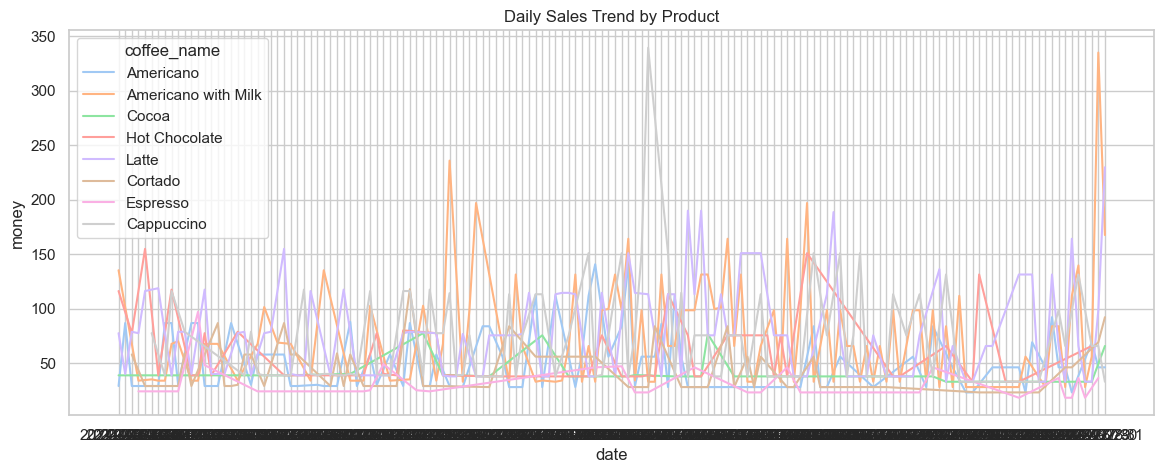

In [5]:
# ============================
# 1. Daily Sales Trend by Product
# ============================
product_trend = df.groupby(['date','coffee_name'])['money'].sum().reset_index()
plt.figure(figsize=(14,5))
sns.lineplot(data=product_trend, x="date", y="money", hue="coffee_name", palette="pastel")
plt.title("Daily Sales Trend by Product")
plt.show()

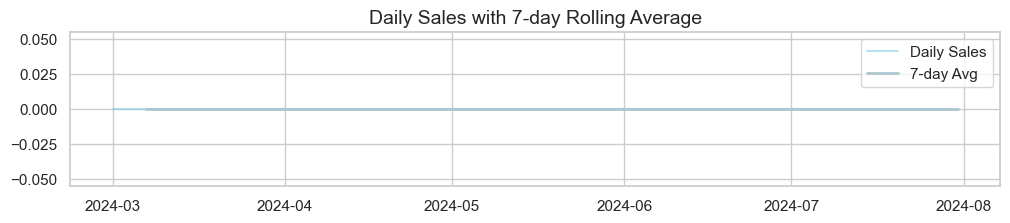

In [6]:
# ============================
# 2. Rolling 7-day Average
# ============================
daily_sales['7d_avg'] = daily_sales['money'].rolling(7).mean()
plt.figure(figsize=(12,2))
plt.plot(daily_sales.index, daily_sales['money'], label="Daily Sales", color="#87CEEB", alpha=0.6)
plt.plot(daily_sales.index, daily_sales['7d_avg'], label="7-day Avg", color="#AEC6CF", linewidth=2)
plt.title("Daily Sales with 7-day Rolling Average", fontsize=14)
plt.legend()
plt.show()

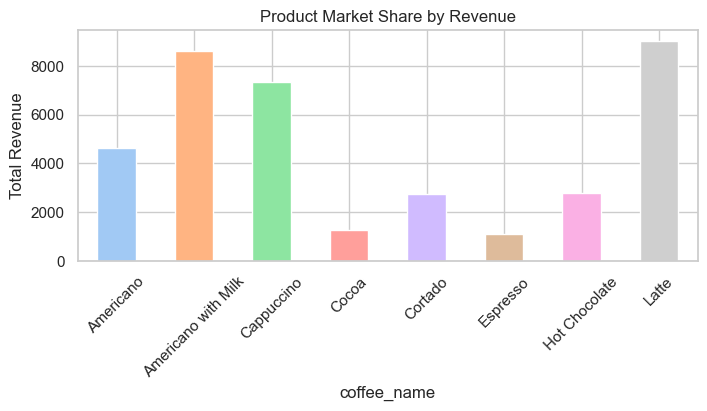

In [7]:
# ============================
# 3. Product Market Share
# ============================
plt.figure(figsize=(8,3))
share = df.groupby("coffee_name")["money"].sum()
share.plot(kind="bar", color=sns.color_palette("pastel"))
plt.title("Product Market Share by Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

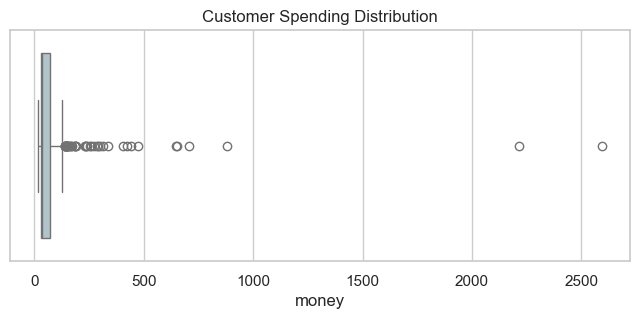

In [7]:
# ============================
# 6. Spending per Customer (Boxplot)
# ============================
customer_spend = df.groupby("card")["money"].sum()
plt.figure(figsize=(8,3))
sns.boxplot(x=customer_spend, color="#AEC6CF")
plt.title("Customer Spending Distribution")
plt.show()

In [8]:
# ---- Model 1: XGBoost Regressor ----
# Create lag features
daily_sales['lag1'] = daily_sales['money'].shift(1)
daily_sales['lag7'] = daily_sales['money'].shift(7)
daily_sales['rolling7'] = daily_sales['money'].rolling(7).mean()

# Drop NaN from lags
ml_df = daily_sales.dropna().reset_index()
X = ml_df[['lag1','lag7','rolling7']]
y = ml_df['money']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

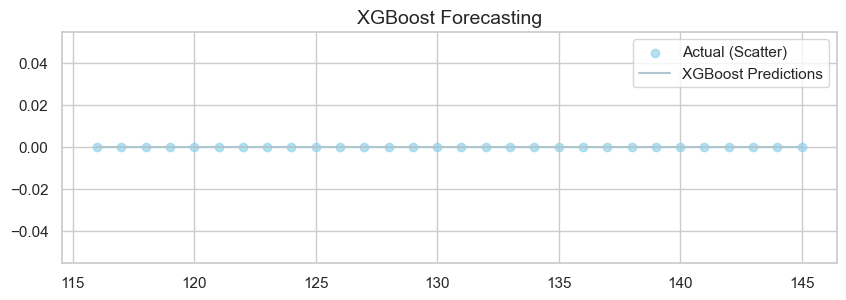

In [27]:
plt.figure(figsize=(10,3))
plt.scatter(y_test.index, y_test.values, color="#87CEEB",alpha=0.6, label="Actual (Scatter)")
plt.plot(y_test.index, y_pred_xgb, label="XGBoost Predictions", color="#AEC6CF")
plt.title("XGBoost Forecasting", fontsize=14)
plt.legend()
plt.show()

In [32]:
# ----- Model 3: Decision Tree Regressor -----

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

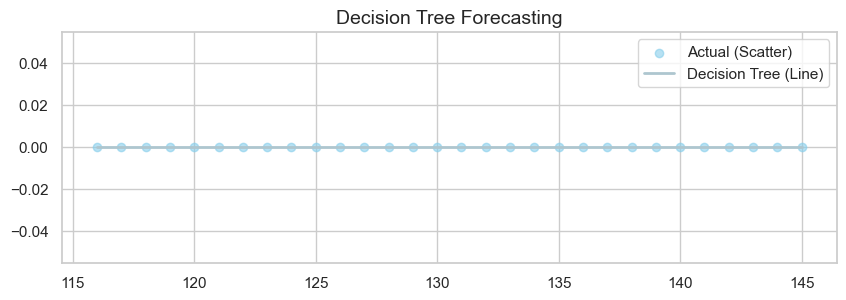

In [31]:
# Scatter + line comparison for Decision Tree
plt.figure(figsize=(10,3))
plt.scatter(y_test.index, y_test.values, color="#87CEEB", alpha=0.6, label="Actual (Scatter)")
plt.plot(y_test.index, y_pred_dt, color="#AEC6CF", linewidth=2, label="Decision Tree (Line)")
plt.title("Decision Tree Forecasting", fontsize=14)
plt.legend()
plt.show()